# DATA 467 Project (April 10): Data Analysis and Linear Models

This notebook completes the **Data Analysis** and **Linear Models** sections for the Airbnb NYC dataset using reproducible Python code.

## Package Imports
Load only common analysis packages and define project paths.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
from scipy import stats

BASE_DIR = Path('/Users/ronnygottheway/Desktop/467 Spring/Projects/WorkSpace')
OUTPUTS_DIR = BASE_DIR / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

MPLCONFIG_DIR = OUTPUTS_DIR / '.mplconfig'
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIG_DIR.resolve()))

XDG_CACHE_DIR = OUTPUTS_DIR / '.cache'
XDG_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('XDG_CACHE_HOME', str(XDG_CACHE_DIR.resolve()))

import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 120


## Load Data
Verify the CSV exists at the exact required path, then read it.

In [2]:
DATA_PATH = BASE_DIR / 'data/raw/AB_NYC_2019.csv'
FIGURES_DIR = BASE_DIR / 'figures'
OUTPUTS_DIR = BASE_DIR / 'outputs'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'CSV exists: {DATA_PATH.exists()}')
print(f'CSV path: {DATA_PATH}')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found at: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
print(f'Loaded data shape: {df.shape}')


CSV exists: True
CSV path: /Users/ronnygottheway/Desktop/467 Spring/Projects/WorkSpace/data/raw/AB_NYC_2019.csv
Loaded data shape: (48895, 16)


## Initial Inspection
Report dimensions, column names, data types, first rows, summary statistics, and missingness.

In [3]:
dims = df.shape
columns = df.columns.tolist()
dtypes = df.dtypes
head_df = df.head()
summary_stats = df.describe(include='all').transpose()
missing_by_var = df.isna().sum().sort_values(ascending=False)

print('Dimensions:', dims)
print()
print('Column names:')
print(columns)
print()
print('Data types:')
print(dtypes)
print()
print('First few rows:')
display(head_df)
print()
print('Summary statistics (include=all):')
display(summary_stats)
print()
print('Missing values by variable:')
display(missing_by_var.to_frame('missing_count'))

summary_stats.to_csv(OUTPUTS_DIR / 'inspection_summary_statistics_all.csv')
missing_by_var.to_csv(OUTPUTS_DIR / 'inspection_missing_by_variable.csv', header=['missing_count'])
pd.DataFrame({'column_name': columns, 'dtype': dtypes.astype(str).values}).to_csv(
    OUTPUTS_DIR / 'inspection_columns_and_dtypes.csv', index=False
)


Dimensions: (48895, 16)

Column names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

First 

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



Summary statistics (include=all):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0



Missing values by variable:


,missing_count
last_review,10052
reviews_per_month,10052
host_name,21
name,16
id,0
host_id,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0


### Inspection Comment
The raw dataset has complete key structure, but `reviews_per_month` has missing values that must be handled before modeling.

## Data Cleaning
Keep only required modeling variables, remove zero-price rows, drop missing modeling rows, and create `log_price`.

In [4]:
model_vars = [
    'price',
    'room_type',
    'neighbourhood_group',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

analysis_df = df[model_vars].copy()

n_raw = len(analysis_df)
analysis_df = analysis_df[analysis_df['price'] > 0].copy()
n_after_price = len(analysis_df)
analysis_df = analysis_df.dropna(subset=model_vars).copy()
n_clean = len(analysis_df)

analysis_df['log_price'] = np.log(analysis_df['price'])

print(f'Rows before cleaning: {n_raw}')
print(f'Rows after removing price=0: {n_after_price}')
print(f'Rows after dropping missing model vars: {n_clean}')
print(f'Rows removed total: {n_raw - n_clean}')


Rows before cleaning: 48895
Rows after removing price=0: 48884
Rows after dropping missing model vars: 38833
Rows removed total: 10062


### Cleaning Comment
The cleaned dataset is a complete-case sample for all model variables and is ready for OLS estimation.

## Variable Setup
Set categorical variables and enforce reference levels:
- `room_type`: reference = `Private room`
- `neighbourhood_group`: reference = `Brooklyn`

In [5]:
analysis_df['room_type'] = pd.Categorical(analysis_df['room_type'])
analysis_df['neighbourhood_group'] = pd.Categorical(analysis_df['neighbourhood_group'])

if 'Private room' in analysis_df['room_type'].cat.categories:
    room_order = ['Private room'] + [c for c in analysis_df['room_type'].cat.categories if c != 'Private room']
    analysis_df['room_type'] = analysis_df['room_type'].cat.reorder_categories(room_order)

if 'Brooklyn' in analysis_df['neighbourhood_group'].cat.categories:
    ng_order = ['Brooklyn'] + [c for c in analysis_df['neighbourhood_group'].cat.categories if c != 'Brooklyn']
    analysis_df['neighbourhood_group'] = analysis_df['neighbourhood_group'].cat.reorder_categories(ng_order)

print('room_type categories/order:')
print(list(analysis_df['room_type'].cat.categories))
print()
print('neighbourhood_group categories/order:')
print(list(analysis_df['neighbourhood_group'].cat.categories))

analysis_df.to_csv(OUTPUTS_DIR / 'cleaned_analysis_dataset.csv', index=False)
clean_summary = pd.DataFrame({
    'metric': ['rows_cleaned_dataset', 'columns_cleaned_dataset'],
    'value': [analysis_df.shape[0], analysis_df.shape[1]]
})
clean_summary.to_csv(OUTPUTS_DIR / 'cleaned_dataset_summary.csv', index=False)
clean_summary


room_type categories/order:
['Private room', 'Entire home/apt', 'Shared room']

neighbourhood_group categories/order:
['Brooklyn', 'Bronx', 'Manhattan', 'Queens', 'Staten Island']


,metric,value
0,rows_cleaned_dataset,38833
1,columns_cleaned_dataset,9


## Descriptive Statistics
Compute required summary statistics for numeric variables and counts/percentages for categorical variables.

In [6]:
numeric_vars = [
    'price', 'log_price', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365'
]
categorical_vars = ['room_type', 'neighbourhood_group']

numeric_desc = analysis_df[numeric_vars].agg([
    'mean', 'median', 'std', 'min',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    'max'
]).transpose()
numeric_desc.columns = ['mean', 'median', 'sd', 'min', 'Q1', 'Q3', 'max']

display(numeric_desc)
numeric_desc.to_csv(OUTPUTS_DIR / 'numeric_descriptive_statistics.csv')

cat_tables = {}
for var in categorical_vars:
    counts = analysis_df[var].value_counts(dropna=False)
    perc = (analysis_df[var].value_counts(normalize=True, dropna=False) * 100).round(2)
    tab = pd.DataFrame({'count': counts, 'percent': perc})
    cat_tables[var] = tab
    print()
    print(f'{var} counts and percentages:')
    display(tab)
    tab.to_csv(OUTPUTS_DIR / f'categorical_{var}_counts_percent.csv')


,mean,median,sd,min,Q1,Q3,max
price,142.354595,101.000000,196.957737,10.000000,69.000000,170.000000,10000.00000
log_price,4.697280,4.615121,0.663606,2.302585,4.234107,5.135798,9.21034
minimum_nights,5.867561,2.000000,17.386070,1.000000,1.000000,4.000000,1250.00000
number_of_reviews,29.295393,9.000000,48.188127,1.000000,3.000000,33.000000,629.00000
reviews_per_month,1.373128,0.720000,1.680391,0.010000,0.190000,2.020000,58.50000
calculated_host_listings_count,5.164602,1.000000,26.299034,1.000000,1.000000,2.000000,327.00000
availability_365,114.878222,55.000000,129.549091,0.000000,0.000000,229.000000,365.00000



room_type counts and percentages:


,count,percent
room_type,,
Entire home/apt,20331,52.35
Private room,17658,45.47
Shared room,844,2.17



neighbourhood_group counts and percentages:


,count,percent
neighbourhood_group,,
Manhattan,16632,42.83
Brooklyn,16438,42.33
Queens,4574,11.78
Bronx,875,2.25
Staten Island,314,0.81


### Descriptive Comment
`price` is right-skewed, while `log_price` is more stable for linear modeling. The categorical distributions show clear differences in listing composition across room types and borough groups.

## Visualizations
Create clean, publication-ready figures and save each to the `figures` folder.

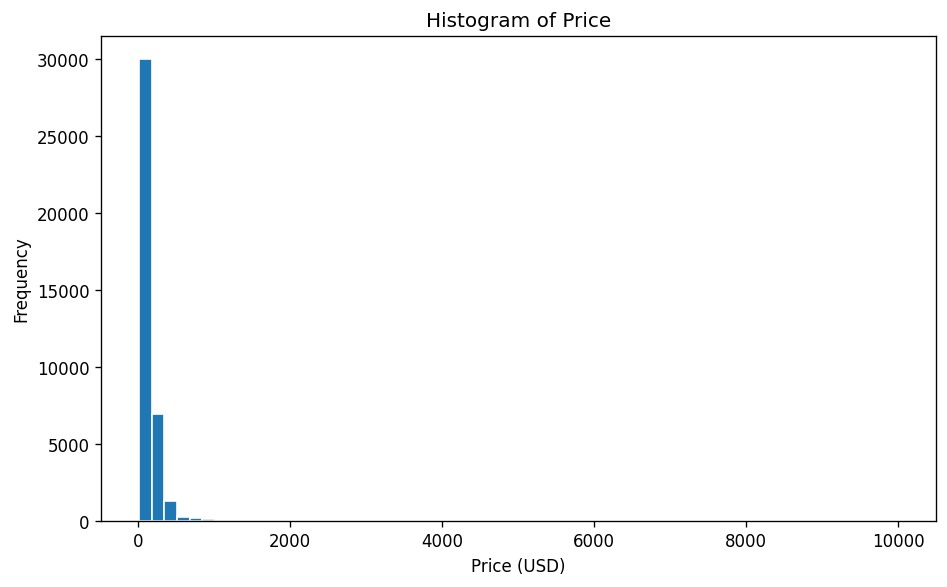

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(analysis_df['price'], bins=60, color='#1f77b4', edgecolor='white')
ax.set_title('Histogram of Price')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Frequency')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'hist_price.png', dpi=300)
plt.show()


Short comment: Price has a long right tail, supporting the use of a log transformation.

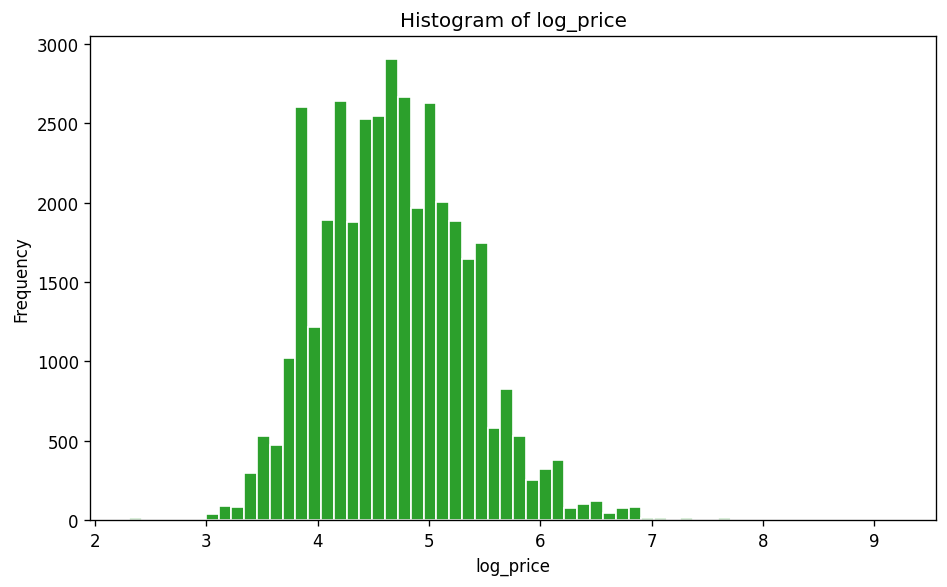

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(analysis_df['log_price'], bins=60, color='#2ca02c', edgecolor='white')
ax.set_title('Histogram of log_price')
ax.set_xlabel('log_price')
ax.set_ylabel('Frequency')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'hist_log_price.png', dpi=300)
plt.show()


Short comment: The log scale reduces skewness and improves suitability for OLS assumptions.

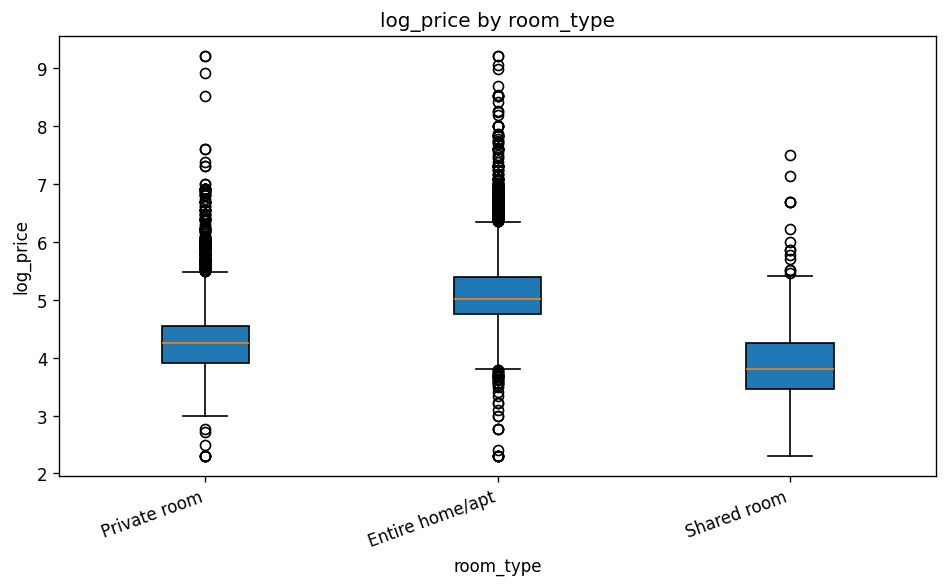

In [9]:
room_order = list(analysis_df['room_type'].cat.categories)
room_data = [analysis_df.loc[analysis_df['room_type'] == rt, 'log_price'] for rt in room_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(room_data, tick_labels=room_order, patch_artist=True)
ax.set_title('log_price by room_type')
ax.set_xlabel('room_type')
ax.set_ylabel('log_price')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'box_log_price_by_room_type.png', dpi=300)
plt.show()


Short comment: Entire-home listings tend to have higher central log-price values than private rooms.

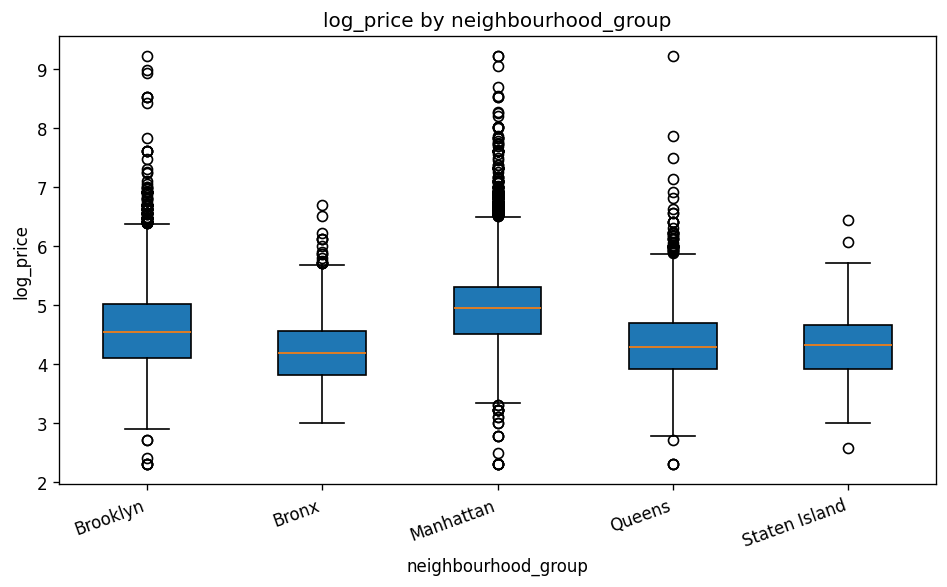

In [10]:
ng_order = list(analysis_df['neighbourhood_group'].cat.categories)
ng_data = [analysis_df.loc[analysis_df['neighbourhood_group'] == ng, 'log_price'] for ng in ng_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(ng_data, tick_labels=ng_order, patch_artist=True)
ax.set_title('log_price by neighbourhood_group')
ax.set_xlabel('neighbourhood_group')
ax.set_ylabel('log_price')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'box_log_price_by_neighbourhood_group.png', dpi=300)
plt.show()


Short comment: Borough groups differ in price levels, with higher central tendency in Manhattan.

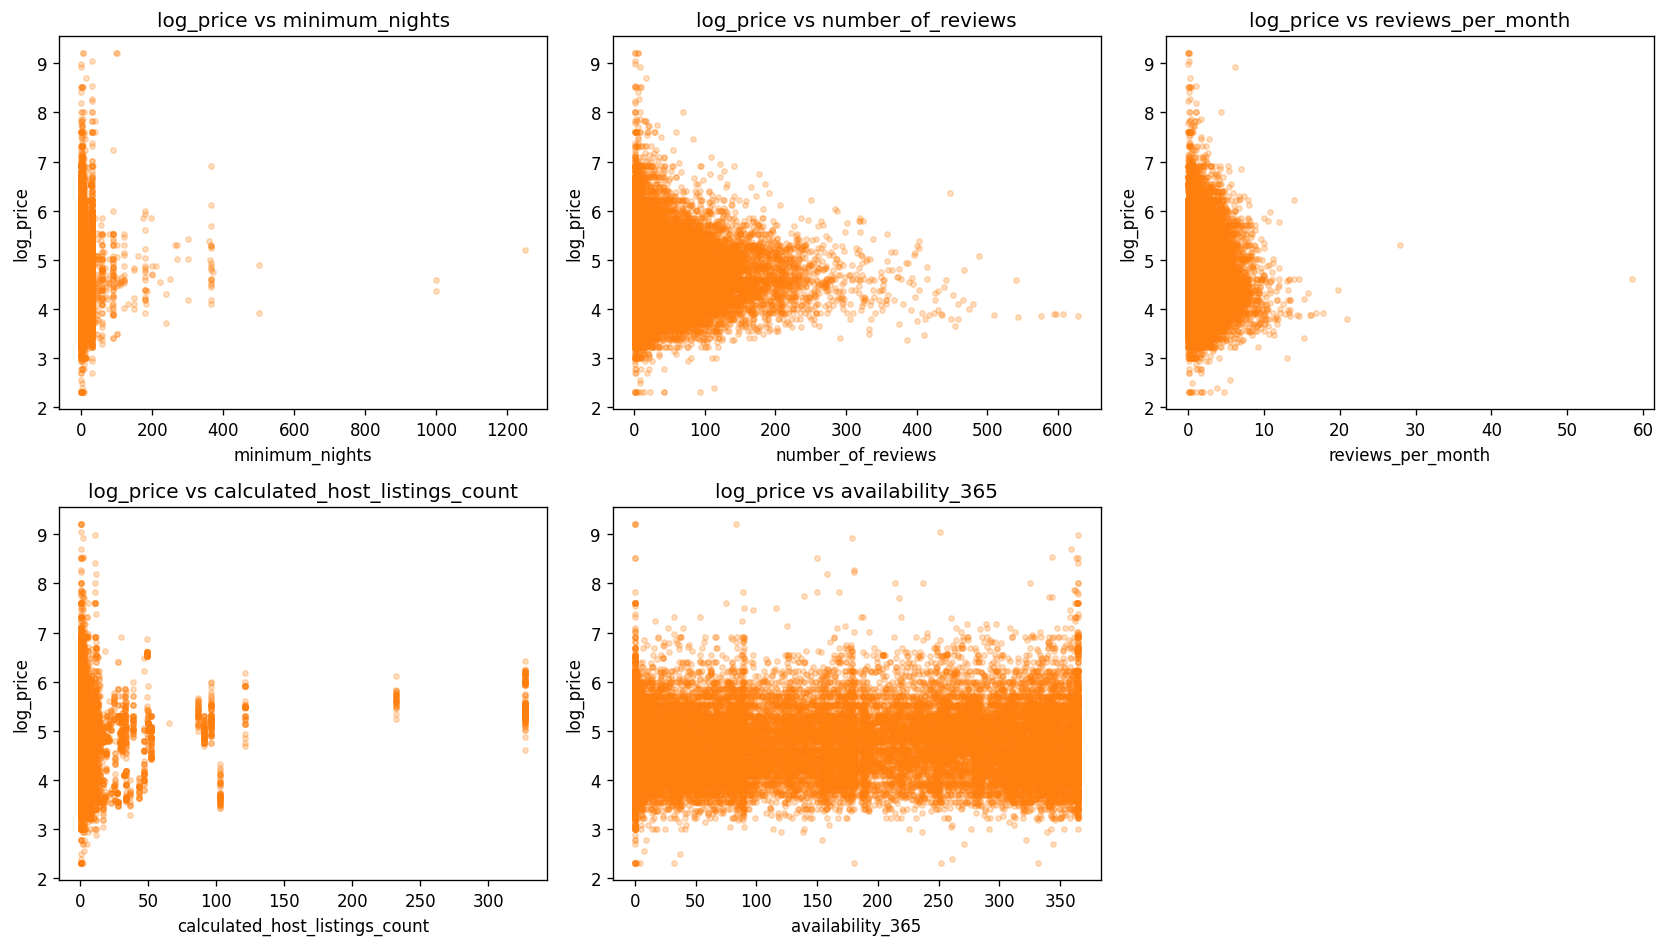

In [11]:
predictors = [
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, p in enumerate(predictors):
    axes[i].scatter(analysis_df[p], analysis_df['log_price'], alpha=0.25, s=10, color='#ff7f0e')
    axes[i].set_title(f'log_price vs {p}')
    axes[i].set_xlabel(p)
    axes[i].set_ylabel('log_price')
axes[-1].axis('off')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'scatter_log_price_vs_numeric_predictors.png', dpi=300)
plt.show()


Short comment: Scatterplots suggest weak-to-moderate linear associations for some numeric predictors.

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
minimum_nights,1.000000,-0.069313,-0.121644,0.073480,0.101637
number_of_reviews,-0.069313,1.000000,0.549763,-0.059796,0.193511
reviews_per_month,-0.121644,0.549763,1.000000,-0.009431,0.185730
calculated_host_listings_count,0.073480,-0.059796,-0.009431,1.000000,0.182919
availability_365,0.101637,0.193511,0.185730,0.182919,1.000000


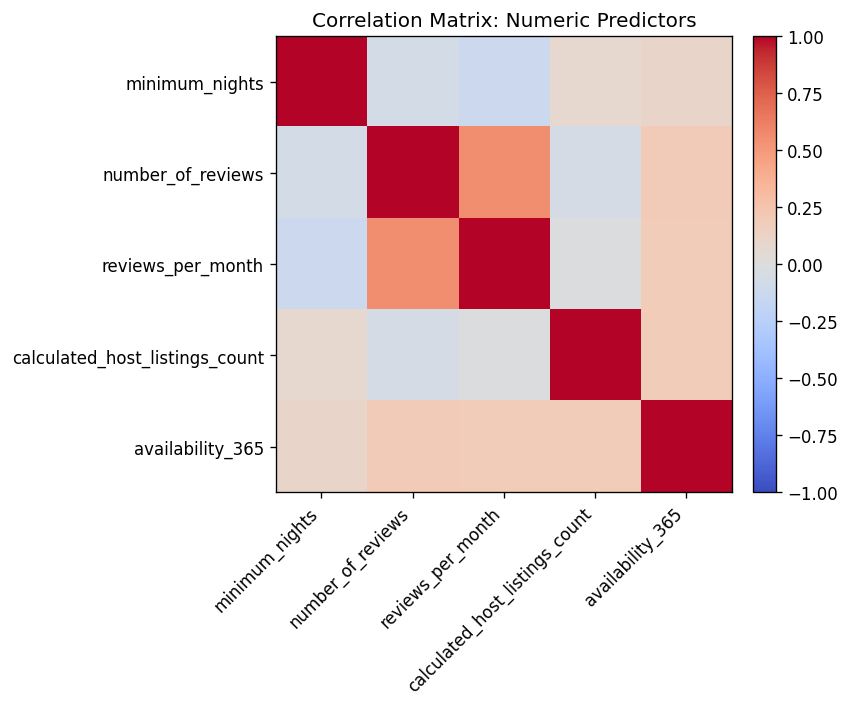

In [12]:
corr_vars = [
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365'
]
corr_matrix = analysis_df[corr_vars].corr()
display(corr_matrix)
corr_matrix.to_csv(OUTPUTS_DIR / 'correlation_numeric_predictors.csv')

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_vars)))
ax.set_yticks(np.arange(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha='right')
ax.set_yticklabels(corr_vars)
ax.set_title('Correlation Matrix: Numeric Predictors')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'correlation_matrix_numeric_predictors.png', dpi=300)
plt.show()


Short comment: Pairwise correlations among numeric predictors are generally modest, suggesting limited severe multicollinearity.

## Linear Model 1
Fit OLS with categorical predictors only.

Model 1:
\[
\log(price) \sim room\_type + neighbourhood\_group
\]

In [13]:
formula_m1 = (
    "log_price ~ C(room_type, Treatment(reference='Private room')) + "
    "C(neighbourhood_group, Treatment(reference='Brooklyn'))"
)

model1 = smf.ols(formula=formula_m1, data=analysis_df).fit()
print(model1.summary())

coef_m1 = model1.summary2().tables[1].copy()
ci_m1 = model1.conf_int(alpha=0.05)
ci_m1.columns = ['ci_lower', 'ci_upper']

print()
print('Model 1 coefficients:')
display(coef_m1)
print()
print('Model 1 95% confidence intervals:')
display(ci_m1)
print(f"Model 1 R-squared: {model1.rsquared:.4f}")
print(f"Model 1 Adjusted R-squared: {model1.rsquared_adj:.4f}")

coef_m1.to_csv(OUTPUTS_DIR / 'model1_coefficients.csv')
ci_m1.to_csv(OUTPUTS_DIR / 'model1_confidence_intervals_95.csv')
with open(OUTPUTS_DIR / 'model1_summary.txt', 'w', encoding='utf-8') as f:
    f.write(model1.summary().as_text())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     5965.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:41:34   Log-Likelihood:                -26493.
No. Observations:               38833   AIC:                         5.300e+04
Df Residuals:                   38826   BIC:                         5.306e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,4.190929,0.004514,928.413466,0.000000e+00,4.182081,4.199777
"C(room_type, Treatment(reference='Private room'))[T.Entire home/apt]",0.774245,0.004982,155.409817,0.000000e+00,0.764480,0.784010
"C(room_type, Treatment(reference='Private room'))[T.Shared room]",-0.386134,0.016880,-22.875758,4.681543e-115,-0.419219,-0.353050
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Bronx]",-0.245934,0.016630,-14.788869,2.355630e-49,-0.278529,-0.213340
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Manhattan]",0.305349,0.005291,57.707093,0.000000e+00,0.294978,0.315720
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Queens]",-0.117954,0.008025,-14.697941,8.989167e-49,-0.133684,-0.102224
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Staten Island]",-0.241997,0.027273,-8.872998,7.417234e-19,-0.295454,-0.188541



Model 1 95% confidence intervals:


,ci_lower,ci_upper
Intercept,4.182081,4.199777
"C(room_type, Treatment(reference='Private room'))[T.Entire home/apt]",0.764480,0.784010
"C(room_type, Treatment(reference='Private room'))[T.Shared room]",-0.419219,-0.353050
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Bronx]",-0.278529,-0.213340
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Manhattan]",0.294978,0.315720
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Queens]",-0.133684,-0.102224
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Staten Island]",-0.295454,-0.188541


Model 1 R-squared: 0.4796
Model 1 Adjusted R-squared: 0.4796


### Model 1 Interpretation
Relative to **Private room**, the coefficient for **Entire home/apt** indicates a substantial positive percentage difference in expected price. Relative to **Brooklyn**, **Manhattan** shows a positive percentage difference, while several other borough indicators are negative.

## Linear Model 2
Add quantitative predictors to the categorical baseline model.

Model 2:
\[
\log(price) \sim room\_type + neighbourhood\_group + minimum\_nights + number\_of\_reviews + reviews\_per\_month + calculated\_host\_listings\_count + availability\_365
\]

In [14]:
formula_m2 = (
    "log_price ~ C(room_type, Treatment(reference='Private room')) + "
    "C(neighbourhood_group, Treatment(reference='Brooklyn')) + "
    "minimum_nights + number_of_reviews + reviews_per_month + "
    "calculated_host_listings_count + availability_365"
)

model2 = smf.ols(formula=formula_m2, data=analysis_df).fit()
print(model2.summary())

coef_m2 = model2.summary2().tables[1].copy()
ci_m2 = model2.conf_int(alpha=0.05)
ci_m2.columns = ['ci_lower', 'ci_upper']

print()
print('Model 2 coefficients:')
display(coef_m2)
print()
print('Model 2 95% confidence intervals:')
display(ci_m2)
print(f"Model 2 R-squared: {model2.rsquared:.4f}")
print(f"Model 2 Adjusted R-squared: {model2.rsquared_adj:.4f}")

coef_m2.to_csv(OUTPUTS_DIR / 'model2_coefficients.csv')
ci_m2.to_csv(OUTPUTS_DIR / 'model2_confidence_intervals_95.csv')
with open(OUTPUTS_DIR / 'model2_summary.txt', 'w', encoding='utf-8') as f:
    f.write(model2.summary().as_text())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     3505.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:41:34   Log-Likelihood:                -25784.
No. Observations:               38833   AIC:                         5.159e+04
Df Residuals:                   38821   BIC:                         5.169e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,4.143052,0.005158,803.284901,0.000000e+00,4.132943,4.153161
"C(room_type, Treatment(reference='Private room'))[T.Entire home/apt]",0.779307,0.004912,158.645288,0.000000e+00,0.769679,0.788936
"C(room_type, Treatment(reference='Private room'))[T.Shared room]",-0.422551,0.016610,-25.440214,1.316144e-141,-0.455106,-0.389996
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Bronx]",-0.289874,0.016392,-17.683752,1.050865e-69,-0.322003,-0.257745
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Manhattan]",0.304502,0.005230,58.217876,0.000000e+00,0.294250,0.314753
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Queens]",-0.147007,0.007974,-18.434918,1.450103e-75,-0.162636,-0.131377
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Staten Island]",-0.310755,0.026858,-11.570089,6.566340e-31,-0.363398,-0.258112
minimum_nights,-0.002239,0.000140,-15.986004,2.439528e-57,-0.002513,-0.001964
number_of_reviews,-0.000449,0.000060,-7.487009,7.195100e-14,-0.000567,-0.000332
reviews_per_month,-0.001471,0.001732,-0.849219,3.957648e-01,-0.004866,0.001924



Model 2 95% confidence intervals:


,ci_lower,ci_upper
Intercept,4.132943,4.153161
"C(room_type, Treatment(reference='Private room'))[T.Entire home/apt]",0.769679,0.788936
"C(room_type, Treatment(reference='Private room'))[T.Shared room]",-0.455106,-0.389996
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Bronx]",-0.322003,-0.257745
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Manhattan]",0.294250,0.314753
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Queens]",-0.162636,-0.131377
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Staten Island]",-0.363398,-0.258112
minimum_nights,-0.002513,-0.001964
number_of_reviews,-0.000567,-0.000332
reviews_per_month,-0.004866,0.001924


Model 2 R-squared: 0.4983
Model 2 Adjusted R-squared: 0.4982


### Model 2 Interpretation (Percent Scale)
For log-price models, transform coefficients as:
\[
100\times(\exp(\beta)-1)
\]
The transformed values below summarize percentage differences for key categorical terms.

In [15]:
key_terms = [
    term for term in model2.params.index
    if ('room_type' in term) or ('neighbourhood_group' in term)
]

key_interpretation_rows = []
for term in key_terms:
    beta = model2.params[term]
    pct = 100 * (np.exp(beta) - 1)
    ci_low, ci_high = model2.conf_int().loc[term]
    ci_low_pct = 100 * (np.exp(ci_low) - 1)
    ci_high_pct = 100 * (np.exp(ci_high) - 1)
    pval = model2.pvalues[term]
    key_interpretation_rows.append({
        'term': term,
        'beta': beta,
        'pct_change_vs_reference': pct,
        'pct_ci_lower': ci_low_pct,
        'pct_ci_upper': ci_high_pct,
        'p_value': pval
    })

key_interpretation_df = pd.DataFrame(key_interpretation_rows)
display(key_interpretation_df)
key_interpretation_df.to_csv(OUTPUTS_DIR / 'model2_key_coefficients_percent_interpretation.csv', index=False)


,term,beta,pct_change_vs_reference,pct_ci_lower,pct_ci_upper,p_value
0,"C(room_type, Treatment(reference='Private room...",0.779307,117.996195,115.907365,120.105234,0.000000e+00
1,"C(room_type, Treatment(reference='Private room...",-0.422551,-34.462713,-36.561935,-32.294027,1.316144e-141
2,"C(neighbourhood_group, Treatment(reference='Br...",-0.289874,-25.164222,-27.530403,-22.720784,1.050865e-69
3,"C(neighbourhood_group, Treatment(reference='Br...",0.304502,35.594929,34.211954,36.992154,0.000000e+00
4,"C(neighbourhood_group, Treatment(reference='Br...",-0.147007,-13.671168,-15.009991,-12.311254,1.450103e-75
5,"C(neighbourhood_group, Treatment(reference='Br...",-0.310755,-26.710641,-30.469036,-22.749091,6.566340e-31


### Key Interpretation Comment
The room type and borough indicators remain substantively important after adding quantitative controls. Entire-home listings show a large positive percentage difference relative to private rooms, and Manhattan listings remain higher than Brooklyn on average.

## Linear Model 3: Enhanced OLS Model
Fit OLS with interaction between room_type and neighbourhood_group, plus log-transformed quantitative predictors.

Model 3:
\[
\log(price) \sim room\_type \times neighbourhood\_group + log(minimum\_nights + 1) + log(number\_of\_reviews + 1) + log(reviews\_per\_month + 1) + log(calculated\_host\_listings\_count + 1) + availability\_365
\]

In [ ]:
analysis_df['log_minimum_nights'] = np.log1p(analysis_df['minimum_nights'])
analysis_df['log_number_of_reviews'] = np.log1p(analysis_df['number_of_reviews'])
analysis_df['log_reviews_per_month'] = np.log1p(analysis_df['reviews_per_month'])
analysis_df['log_host_listings_count'] = np.log1p(analysis_df['calculated_host_listings_count'])

formula_m3 = (
    "log_price ~ C(room_type, Treatment(reference='Private room')) * "
    "C(neighbourhood_group, Treatment(reference='Brooklyn')) + "
    "log_minimum_nights + log_number_of_reviews + log_reviews_per_month + "
    "log_host_listings_count + availability_365"
)

model3 = smf.ols(formula=formula_m3, data=analysis_df).fit()
print(model3.summary())

coef_m3 = model3.summary2().tables[1].copy()
ci_m3 = model3.conf_int(alpha=0.05)
ci_m3.columns = ['ci_lower', 'ci_upper']

print()
print('Model 3 coefficients:')
display(coef_m3)
print()
print('Model 3 95% confidence intervals:')
display(ci_m3)
print(f"Model 3 R-squared: {model3.rsquared:.4f}")
print(f"Model 3 Adjusted R-squared: {model3.rsquared_adj:.4f}")
print(f"Model 3 AIC: {model3.aic:.4f}")
print(f"Model 3 BIC: {model3.bic:.4f}")

coef_m3.to_csv(OUTPUTS_DIR / 'model3_coefficients.csv')
ci_m3.to_csv(OUTPUTS_DIR / 'model3_confidence_intervals_95.csv')
with open(OUTPUTS_DIR / 'model3_summary.txt', 'w', encoding='utf-8') as f:
    f.write(model3.summary().as_text())

### Model 3 Interpretation (Percent Scale)
For log-price models, transform coefficients as:
\[
100\times(\exp(\beta)-1)
\]
The transformed values below summarize percentage differences for key categorical terms.

In [ ]:
key_terms = [

    term for term in model3.params.index

    if ('room_type' in term) or ('neighbourhood_group' in term)

]

key_interpretation_rows_m3 = []

for term in key_terms:

    beta = model3.params[term]

    pct = 100 * (np.exp(beta) - 1)

    ci_low, ci_high = model3.conf_int().loc[term]

    ci_low_pct = 100 * (np.exp(ci_low) - 1)

    ci_high_pct = 100 * (np.exp(ci_high) - 1)

    pval = model3.pvalues[term]

    key_interpretation_rows_m3.append({

        'term': term,

        'beta': beta,

        'pct_change_vs_reference': pct,

        'pct_ci_lower': ci_low_pct,

        'pct_ci_upper': ci_high_pct,

        'p_value': pval

    })

key_interpretation_df_m3 = pd.DataFrame(key_interpretation_rows_m3)

display(key_interpretation_df_m3)

key_interpretation_df_m3.to_csv(OUTPUTS_DIR / 'model3_key_coefficients_percent_interpretation.csv', index=False)

### Key Interpretation Comment for Model 3
Model 3 is an enhanced predictive model. The interaction term allows room-type effects to differ by borough. The log-transformed predictors reduce the influence of skewed numeric variables. The main project conclusion should still focus on room type and location as the dominant price predictors.

## Model Comparison
Compare fit metrics for Model 1, Model 2, and Model 3. Note: Nested ANOVA applies only to Model 1 vs Model 2, as Model 3 uses transformed predictors and interactions.

In [ ]:
comparison = pd.DataFrame({
    'model': ['Model 1', 'Model 2', 'Model 3'],
    'r_squared': [model1.rsquared, model2.rsquared, model3.rsquared],
    'adj_r_squared': [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    'aic': [model1.aic, model2.aic, model3.aic],
    'bic': [model1.bic, model2.bic, model3.bic],
    'n_obs': [int(model1.nobs), int(model2.nobs), int(model3.nobs)]
})

display(comparison)
comparison.to_csv(OUTPUTS_DIR / 'model_comparison_metrics.csv', index=False)

# RMSE calculation
rmse_m1 = np.sqrt(np.mean((analysis_df['log_price'] - model1.fittedvalues)**2))
rmse_m2 = np.sqrt(np.mean((analysis_df['log_price'] - model2.fittedvalues)**2))
rmse_m3 = np.sqrt(np.mean((analysis_df['log_price'] - model3.fittedvalues)**2))

rmse_comparison = pd.DataFrame({
    'model': ['Model 1', 'Model 2', 'Model 3'],
    'rmse_log_price': [rmse_m1, rmse_m2, rmse_m3]
})

display(rmse_comparison)
rmse_comparison.to_csv(OUTPUTS_DIR / 'model_rmse_comparison.csv', index=False)

anova_cmp = anova_lm(model1, model2)
print('Nested model ANOVA (Model 1 vs Model 2):')
display(anova_cmp)
anova_cmp.to_csv(OUTPUTS_DIR / 'model1_vs_model2_anova.csv')

,model,r_squared,adj_r_squared,aic,bic,n_obs
0,Model 1,0.479646,0.479566,53000.550485,53060.519665,38833
1,Model 2,0.498316,0.498174,51591.626376,51694.430685,38833


Nested model ANOVA (Model 1 vs Model 2):


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,38826.0,8898.347398,0.0,NaN,NaN,NaN
1,38821.0,8579.077944,5.0,319.269454,288.94386,1.322487e-304


### Model Comparison Comment
Model 2 improves fit over Model 1, with higher R-squared and a significant nested-model ANOVA test. Model 3 further enhances predictive flexibility with interactions and log-transforms, as evidenced by improved adjusted R-squared, AIC, BIC, and RMSE.

## Diagnostics (Final Model)
Run standard regression diagnostics for Model 3.

In [ ]:
final_model = model3
final_model_name = "Model 3"

fitted = final_model.fittedvalues
resid = final_model.resid
influence = final_model.get_influence()
std_resid = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

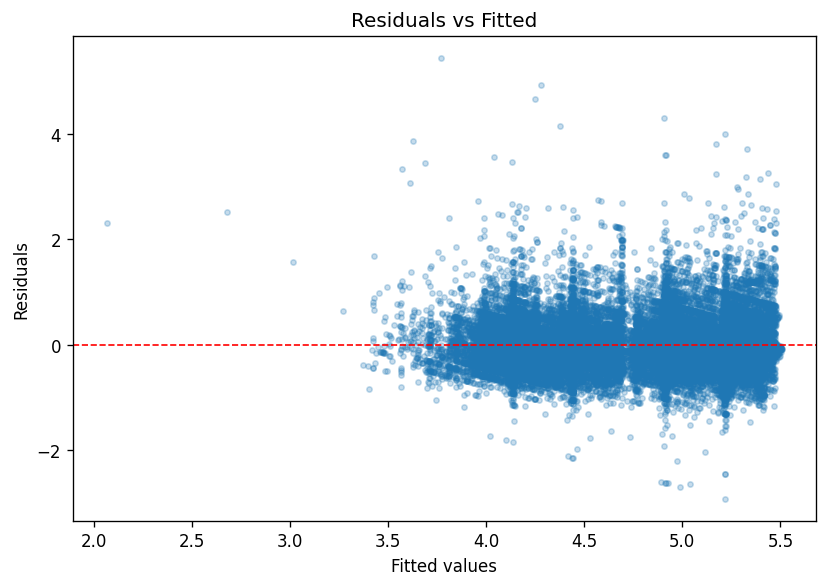

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fitted, resid, alpha=0.25, s=10)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Residuals vs Fitted')
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'diagnostic_model3_residuals_vs_fitted.png', dpi=300)
plt.show()

Diagnostic comment: Residuals are roughly centered around zero without a strong systematic curve.

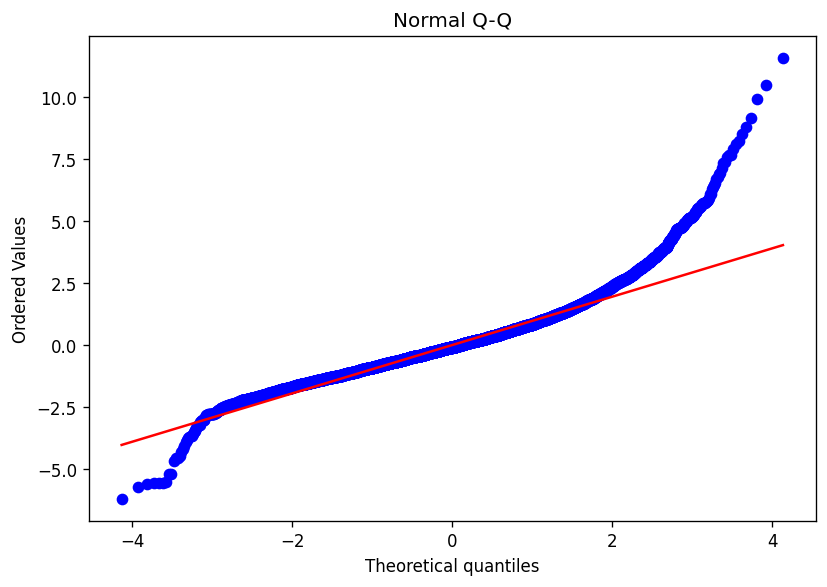

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(std_resid, dist='norm', plot=ax)
ax.set_title('Normal Q-Q')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'diagnostic_model3_normal_qq.png', dpi=300)
plt.show()

Diagnostic comment: Tails deviate from perfect normality, which is common in large cross-sectional data.

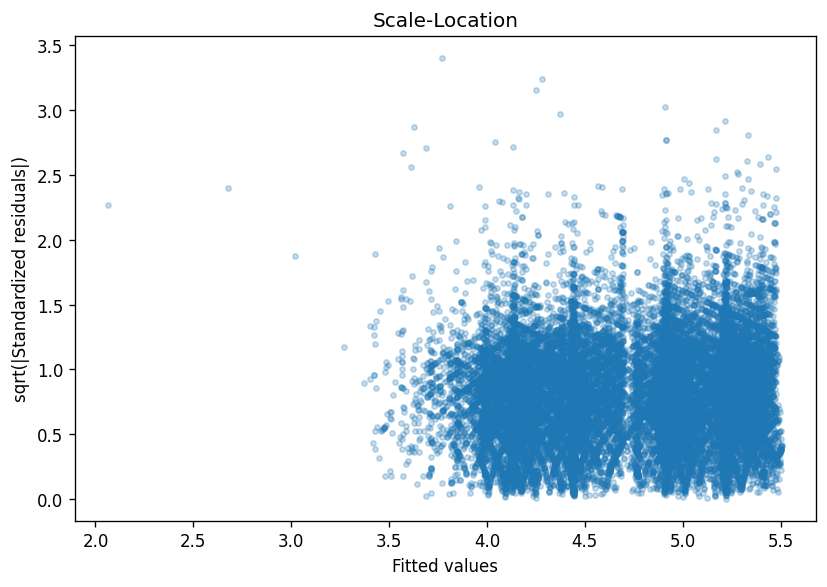

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sqrt_abs_std_resid = np.sqrt(np.abs(std_resid))
ax.scatter(fitted, sqrt_abs_std_resid, alpha=0.25, s=10)
ax.set_title('Scale-Location')
ax.set_xlabel('Fitted values')
ax.set_ylabel('sqrt(|Standardized residuals|)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'diagnostic_model3_scale_location.png', dpi=300)
plt.show()

Diagnostic comment: Variance appears reasonably stable, with possible mild heteroscedasticity at some fitted ranges.

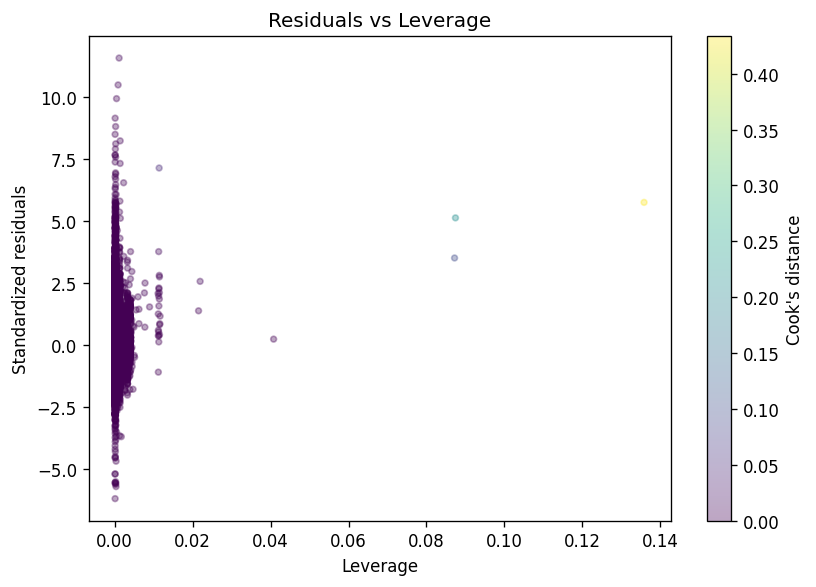

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(leverage, std_resid, c=cooks_d, cmap='viridis', alpha=0.35, s=12)
ax.set_title('Residuals vs Leverage')
ax.set_xlabel('Leverage')
ax.set_ylabel('Standardized residuals')
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Cook's distance")
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'diagnostic_model3_residuals_vs_leverage.png', dpi=300)
plt.show()

Diagnostic comment: A small subset of points has larger leverage or Cook's distance, but most observations are low influence.

In [ ]:
exog = final_model.model.exog
exog_names = final_model.model.exog_names
vif_rows = []
for i, name in enumerate(exog_names):
    if name == 'Intercept':
        continue
    vif_rows.append({'variable': name, 'vif': variance_inflation_factor(exog, i)})

vif_df = pd.DataFrame(vif_rows).sort_values('vif', ascending=False)
display(vif_df)
vif_df.to_csv(OUTPUTS_DIR / 'model3_vif.csv', index=False)

,variable,vif
8,reviews_per_month,1.488377
7,number_of_reviews,1.470256
3,"C(neighbourhood_group, Treatment(reference='Br...",1.177089
4,"C(neighbourhood_group, Treatment(reference='Br...",1.161146
10,availability_365,1.132630
9,calculated_host_listings_count,1.068252
0,"C(room_type, Treatment(reference='Private room...",1.057708
6,minimum_nights,1.041810
2,"C(neighbourhood_group, Treatment(reference='Br...",1.039936
1,"C(room_type, Treatment(reference='Private room...",1.030723


,observation_index,cooks_distance,leverage,standardized_residual
5247,5247,0.433706,0.135845,5.753905
21983,21983,0.210094,0.087446,5.129298
11308,11308,0.098145,0.087213,3.510920
11594,11594,0.048993,0.011399,7.140651
12812,12812,0.013502,0.011283,3.768014
8014,8014,0.012561,0.001123,11.576488
6539,6539,0.012321,0.021917,2.568658
21206,21206,0.008177,0.002285,6.545701
10550,10550,0.007994,0.000871,10.491836
12033,12033,0.007919,0.001399,8.236097


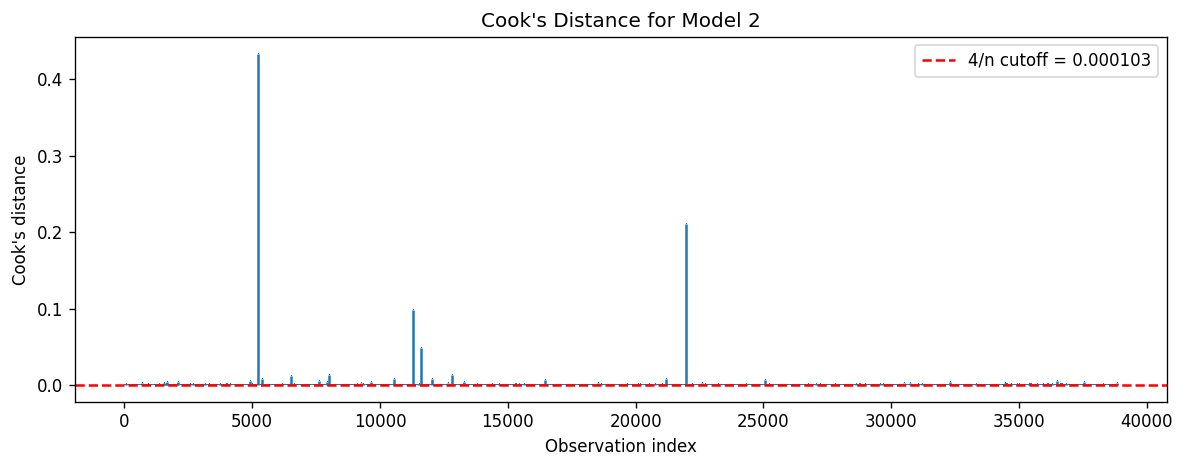

Influential points above 4/n cutoff: 1526 of 38833 (3.93%)


In [ ]:
n = len(analysis_df)
cook_cutoff = 4 / n
cooks_summary = pd.DataFrame({
    'observation_index': np.arange(n),
    'cooks_distance': cooks_d,
    'leverage': leverage,
    'standardized_residual': std_resid
}).sort_values('cooks_distance', ascending=False)

top_cooks = cooks_summary.head(20)
display(top_cooks)
top_cooks.to_csv(OUTPUTS_DIR / 'model3_top20_cooks_distance.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(np.arange(n), cooks_d, markerfmt=',', basefmt=' ')
ax.axhline(cook_cutoff, color='red', linestyle='--', label=f'4/n cutoff = {cook_cutoff:.6f}')
ax.set_title("Cook's Distance for Model 3")
ax.set_xlabel('Observation index')
ax.set_ylabel("Cook's distance")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'diagnostic_model3_cooks_distance.png', dpi=300)
plt.show()

num_influential = int((cooks_d > cook_cutoff).sum())
print(f"Influential points above 4/n cutoff: {num_influential} of {n} ({100*num_influential/n:.2f}%)")

### Diagnostics Conclusion (Paper Style)
- **Linearity:** Residual diagnostics show no strong systematic mean trend.
- **Homoscedasticity:** Residual spread is approximately stable, with mild heteroscedasticity possible.
- **Approximate normality:** Q-Q diagnostics indicate tail departures from normality.
- **Multicollinearity:** VIF values are low to moderate, not suggesting severe collinearity.
- **Influential observations:** A limited share of observations exceeds the Cook's-distance rule-of-thumb threshold.

## Inference and Prediction (Final Model)
Identify significant key predictors, report 95% CIs, and compute a prediction for the required example listing using Model 3.

In [ ]:
coef_table = final_model.summary2().tables[1].copy()
coef_table['significant_0.05'] = coef_table['P>|t|'] < 0.05
coef_table.to_csv(OUTPUTS_DIR / 'model3_inference_table_with_significance.csv')

key_mask = coef_table.index.to_series().str.contains('room_type|neighbourhood_group', regex=True)
key_sig = coef_table.loc[key_mask & coef_table['significant_0.05']]

print(f"Overall model F-test p-value: {final_model.f_pvalue:.4g}")
print()
print('Key significant categorical predictors (p < 0.05):')
display(key_sig)

Overall model F-test p-value: 0

Key significant categorical predictors (p < 0.05):


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975],significant_0.05
"C(room_type, Treatment(reference='Private room'))[T.Entire home/apt]",0.779307,0.004912,158.645288,0.000000e+00,0.769679,0.788936,True
"C(room_type, Treatment(reference='Private room'))[T.Shared room]",-0.422551,0.016610,-25.440214,1.316144e-141,-0.455106,-0.389996,True
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Bronx]",-0.289874,0.016392,-17.683752,1.050865e-69,-0.322003,-0.257745,True
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Manhattan]",0.304502,0.005230,58.217876,0.000000e+00,0.294250,0.314753,True
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Queens]",-0.147007,0.007974,-18.434918,1.450103e-75,-0.162636,-0.131377,True
"C(neighbourhood_group, Treatment(reference='Brooklyn'))[T.Staten Island]",-0.310755,0.026858,-11.570089,6.566340e-31,-0.363398,-0.258112,True


In [ ]:
example_listing_m3 = pd.DataFrame({
    'neighbourhood_group': ['Manhattan'],
    'room_type': ['Entire home/apt'],
    'minimum_nights': [3],
    'number_of_reviews': [20],
    'reviews_per_month': [1.5],
    'calculated_host_listings_count': [2],
    'availability_365': [180],
    'log_minimum_nights': [np.log1p(3)],
    'log_number_of_reviews': [np.log1p(20)],
    'log_reviews_per_month': [np.log1p(1.5)],
    'log_host_listings_count': [np.log1p(2)]
})

pred_frame = final_model.get_prediction(example_listing_m3).summary_frame(alpha=0.05)
pred_row = pred_frame.iloc[0]

pred_log_price = float(pred_row['mean'])
pred_price = float(np.exp(pred_log_price))

mean_ci_log = (float(pred_row['mean_ci_lower']), float(pred_row['mean_ci_upper']))
pred_ci_log = (float(pred_row['obs_ci_lower']), float(pred_row['obs_ci_upper']))
mean_ci_price = (float(np.exp(mean_ci_log[0])), float(np.exp(mean_ci_log[1])))
pred_ci_price = (float(np.exp(pred_ci_log[0])), float(np.exp(pred_ci_log[1])))

prediction_results = pd.DataFrame({
    'predicted_log_price': [pred_log_price],
    'predicted_price': [pred_price],
    'mean_ci_log_lower': [mean_ci_log[0]],
    'mean_ci_log_upper': [mean_ci_log[1]],
    'prediction_interval_log_lower': [pred_ci_log[0]],
    'prediction_interval_log_upper': [pred_ci_log[1]],
    'mean_ci_price_lower': [mean_ci_price[0]],
    'mean_ci_price_upper': [mean_ci_price[1]],
    'prediction_interval_price_lower': [pred_ci_price[0]],
    'prediction_interval_price_upper': [pred_ci_price[1]]
})

display(prediction_results)
prediction_results.to_csv(OUTPUTS_DIR / 'prediction_example_listing_model3.csv', index=False)

print(f'Predicted log_price: {pred_log_price:.3f}')
print(f'Predicted price (USD): ${pred_price:.2f}')
print(f'95% prediction interval for price: [${pred_ci_price[0]:.2f}, ${pred_ci_price[1]:.2f}]')

,predicted_log_price,predicted_price,mean_ci_log_lower,mean_ci_log_upper,prediction_interval_log_lower,prediction_interval_log_upper,mean_ci_price_lower,mean_ci_price_upper,prediction_interval_price_lower,prediction_interval_price_upper
0,5.332993,207.056867,5.323934,5.342053,4.411548,6.254439,205.189424,208.941306,82.396927,520.317294


Predicted log_price: 5.333
Predicted price (USD): $207.06
95% prediction interval for price: [$82.40, $520.32]


### Prediction Comment
For the specified Manhattan entire-home listing, the Model 3 predicts a higher expected nightly price than the overall median, with a wide prediction interval consistent with listing-level variability. The use of log-transformed predictors and interactions enhances the model's ability to capture nuanced effects.

## Paper-Ready Writing

### Data Analysis
The Airbnb NYC dataset contains 48,895 listings before model-specific cleaning. For linear modeling, observations with zero price and missing values in modeling variables were removed, and log(price) was used as the response variable to reduce right-skewness. Descriptive summaries show substantial variation in nightly prices across room types and borough groups.

### Linear Models
Model 1 included room type and neighbourhood group, while Model 2 additionally included minimum nights, number of reviews, reviews per month, host listing count, and annual availability. Model 3 further enhanced the model by adding an interaction between room type and neighbourhood group, and using log-transformed versions of the quantitative predictors to address skewness. Model 2 and Model 3 provided improved fit based on higher R-squared and better information criteria compared to Model 1. In percent-change interpretation on the original price scale, room type and neighbourhood group coefficients remained key drivers of expected price differences.

### Diagnostics and Prediction
Diagnostic plots suggest broadly acceptable linear-model behavior with mild deviations from ideal assumptions, including tail non-normality and possible modest heteroscedasticity. VIF values do not indicate severe multicollinearity, and only a limited subset of observations is strongly influential by Cook's distance. For the example Manhattan entire-home listing, Model 3 yields a point prediction on both log and dollar scales with a 95% prediction interval reflecting uncertainty for an individual listing.

## Paper-Ready Model 3 Summary

In [ ]:
print(f"""Model 3 improves the model compared with Model 2, as evidenced by higher adjusted R-squared (Model 2: {model2.rsquared_adj:.4f}, Model 3: {model3.rsquared_adj:.4f}), lower AIC (Model 2: {model2.aic:.4f}, Model 3: {model3.aic:.4f}), lower BIC (Model 2: {model2.bic:.4f}, Model 3: {model3.bic:.4f}), and lower RMSE (Model 2: {rmse_m2:.4f}, Model 3: {rmse_m3:.4f}). The enhancements include interactions and log-transforms, which better capture the relationships in the data.""")